# EXAMEN I

ALUMNO: Navarrete Tepozan Ivan
        320241697

In [1]:
from bs4 import BeautifulSoup
import  polars as pl
import requests
import re
import os
import rarfile
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


# *WEB SCRAPPING*

Aqui se accede a la apgina web y se recupera el html,
se encuentran todas las etiquetas del htm que corresponde a las descargas
y se guardan en una lista

In [2]:
Pag = "https://datos.profeco.gob.mx/datos_abiertos/"
LaPagina= requests.get(Pag+'qqp.php')
html = LaPagina.text
html_Completo = BeautifulSoup(html, 'html.parser')
Clase_busqueda = html_Completo.find_all('div', class_="form-group")
ExtructuraABuscar=r'href="([^>]+)">'
elemento= Clase_busqueda[0].prettify()
ListaLinks=re.findall(ExtructuraABuscar,elemento)
NombresArchivos=Clase_busqueda[0].find_all('a')
NombresArchivos=[x.text + '.rar' for x in NombresArchivos]
ruta_base=os.getcwd()

Aqui se descargan los archivos .rar en la carpeta donde se ejecuta el código

In [3]:
for link, nombre in zip(ListaLinks, NombresArchivos):
    nombre = nombre
    print(f"Descargando: {nombre} desde {Pag+link}")
    
    respuesta = requests.get(Pag+link, stream=True)
    
    if respuesta.status_code == 200:
        ruta_local = os.path.join(ruta_base, nombre)
        with open(ruta_local, "wb") as f:
            for chunk in respuesta.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Guardado en: {ruta_local}")
    else:
        print(f"Error al descargar {nombre}: {respuesta.status_code}")

Descargando: Base de Datos Histórica Quién es Quién en los Precios 2025.rar desde https://datos.profeco.gob.mx/datos_abiertos/file.php?t=e100d5241e1f21ecdc8fd96cf2de7a09
Guardado en: c:\Users\xboxn\Documents\pythonPraticas\SI\Examen1\Base de Datos Histórica Quién es Quién en los Precios 2025.rar
Descargando: Base de Datos Histórica Quién es Quién en los Precios 2024.rar desde https://datos.profeco.gob.mx/datos_abiertos/file.php?t=4af96007e16916edb17ef6f9279e7016
Guardado en: c:\Users\xboxn\Documents\pythonPraticas\SI\Examen1\Base de Datos Histórica Quién es Quién en los Precios 2024.rar
Descargando: Base de Datos Histórica Quién es Quién en los Precios 2023.rar desde https://datos.profeco.gob.mx/datos_abiertos/file.php?t=f3270d227f2966e6138a3ed41a9bbfb7
Guardado en: c:\Users\xboxn\Documents\pythonPraticas\SI\Examen1\Base de Datos Histórica Quién es Quién en los Precios 2023.rar
Descargando: Base de Datos Histórica Quién es Quién en los Precios 2022.rar desde https://datos.profeco.gob.m

# *DESCOMPRIMIR .CSV's Y JUNTAR EN DATAFRAMES*

Luego se crea una carpeta donde se descomprimen los .rar, despues de la eliminación de los .rar
si la extracción del archivo es correcta se borra el .rar

In [3]:
Carpeta_nombre="Descomprimidos"
ruta_completa = os.path.join(ruta_base, Carpeta_nombre)
os.makedirs(ruta_completa, exist_ok=True)

In [5]:
for nombre_archivo in NombresArchivos:
    print(f"Descomprimiendo {nombre_archivo}")
    ruta_local = os.path.join(ruta_base, nombre_archivo)

    try:
        with rarfile.RarFile(ruta_local, 'r') as rf:
            rf.extractall(path=ruta_completa)
        print(f"\t'{nombre_archivo}' descomprimido con éxito.")
        os.remove(ruta_local)
    except rarfile.Error as e:
        print(f"No se pudo descomprimir {nombre_archivo}: {e}")



Descomprimiendo Base de Datos Histórica Quién es Quién en los Precios 2025.rar
	'Base de Datos Histórica Quién es Quién en los Precios 2025.rar' descomprimido con éxito.
Descomprimiendo Base de Datos Histórica Quién es Quién en los Precios 2024.rar
	'Base de Datos Histórica Quién es Quién en los Precios 2024.rar' descomprimido con éxito.
Descomprimiendo Base de Datos Histórica Quién es Quién en los Precios 2023.rar
	'Base de Datos Histórica Quién es Quién en los Precios 2023.rar' descomprimido con éxito.
Descomprimiendo Base de Datos Histórica Quién es Quién en los Precios 2022.rar
	'Base de Datos Histórica Quién es Quién en los Precios 2022.rar' descomprimido con éxito.
Descomprimiendo Base de Datos Histórica Quién es Quién en los Precios 2021.rar
	'Base de Datos Histórica Quién es Quién en los Precios 2021.rar' descomprimido con éxito.
Descomprimiendo Base de Datos Histórica Quién es Quién en los Precios 2020.rar
	'Base de Datos Histórica Quién es Quién en los Precios 2020.rar' desco

se crea un diccionario que guardara los dataframes con los datos de cada año,
NOTA: se intento guardar todo en un df, pero mi compu explotaba jajaja, mejor por separado

In [4]:
Encabezados = {
    'PRODUCTO': pl.Utf8,
    'DESCRIPCION': pl.Utf8,
    'MARCA': pl.Categorical,
    'CATEGORIA': pl.Categorical,
    'SUBCATEGORIA': pl.Categorical,
    'PRECIO': pl.Float32,
    'FECHA_REGISTRO': pl.Date,
    'PROVEEDOR': pl.Categorical,
    'TIPO_PROVEEDOR': pl.Categorical,
    'SUCURSAL': pl.Categorical,
    'DIRECCION': pl.Utf8,
    'ESTADO': pl.Categorical,
    'MUNICIPIO': pl.Categorical,
    'LATITUD': pl.Float32,
    'LONGITUD': pl.Float32
}

dfs = {"2015":None,"2016":None,"2017":None,"2018":None,"2019":None,"2020":None,"2021":None,"2022":None,"2023":None,"2024":None,"2025":None}

Lista_dfs=[]
for anno in range(2015,2026):
    for carpeta_raiz, _, archivos in os.walk(ruta_base + '/Descomprimidos/'+str(anno)):
        for archivo in archivos:
            try:
                ruta_archivo = os.path.join(carpeta_raiz, archivo)
                df = None
                df = pl.read_csv(
                ruta_archivo,
                has_header=False,
                new_columns=list(Encabezados.keys()),
                schema_overrides=Encabezados,
                null_values="NULL",
                encoding="utf8"
                )
                print(f"Abierto: {archivo}")
                if df is not None:
                    Lista_dfs.append(df)
            except Exception as e:
                try:
                    df = pl.read_csv(
                        ruta_archivo,
                        has_header=False,
                        new_columns=list(Encabezados.keys()),
                        schema_overrides=Encabezados,
                        null_values="NULL",
                        encoding="latin1"
                    )
                    if df is not None:
                        Lista_dfs.append(df)
                    print(f"Abierto: {archivo}")
                except Exception as e_fallback:
                    print(f"Error al abrir {archivo}: {e_fallback}")
    if Lista_dfs:
        dfs[str(anno)]=pl.concat(Lista_dfs, how="vertical")
        print(f"\nConcatenación exitosa para el año{anno}\n")
    else:
        print(f"\nNo se cargó ningún archivo para el año{anno}.\n")
    
    Lista_dfs=[]
        
        



Abierto: 012015.csv
Abierto: 022015.csv
Abierto: 032015.csv
Abierto: 042015.csv
Abierto: 052015.csv
Abierto: 062015.csv
Abierto: 072015.csv
Abierto: 082015.csv
Abierto: 092015.csv
Abierto: 102015.csv
Abierto: 112015.csv
Abierto: 122015.csv
Abierto: 132015.csv
Abierto: 142015.csv
Abierto: 152015.csv
Abierto: 162015.csv
Abierto: 172015.csv
Abierto: 182015.csv
Abierto: 192015.csv
Abierto: 202015.csv
Abierto: 212015.csv
Abierto: 222015.csv
Abierto: 232015.csv
Abierto: 242015.csv
Abierto: 252015.csv
Abierto: 262015.csv
Abierto: 272015.csv
Abierto: 282015.csv
Abierto: 292015.csv
Abierto: 302015.csv
Abierto: 312015.csv
Abierto: 322015.csv
Abierto: 332015.csv
Abierto: 342015.csv
Abierto: 352015.csv
Abierto: 362015.csv
Abierto: 372015.csv
Abierto: 382015.csv
Abierto: 392015.csv
Abierto: 402015.csv
Abierto: 412015.csv
Abierto: 422015.csv
Abierto: 432015.csv
Abierto: 442015.csv
Abierto: 452015.csv
Abierto: 462015.csv
Abierto: 472015.csv
Abierto: 482015.csv
Abierto: 492015.csv
Abierto: 502015.csv


# *ANÁLSIS EXPLORATORIO Y PREPOCESAMIENTO*

Primero reviso el tipo de los datos y estádisticas básicas de Las variables cuaitativas

In [5]:
print(dfs["2015"].schema)
for i in range (2015,2026):
    print(f"\nDATOS DE {i}...\n ")
    print(dfs[str(i)].select(["PRECIO","LATITUD", "LONGITUD"]).describe())

Schema([('PRODUCTO', String), ('DESCRIPCION', String), ('MARCA', Categorical), ('CATEGORIA', Categorical), ('SUBCATEGORIA', Categorical), ('PRECIO', Float32), ('FECHA_REGISTRO', Date), ('PROVEEDOR', Categorical), ('TIPO_PROVEEDOR', Categorical), ('SUCURSAL', Categorical), ('DIRECCION', String), ('ESTADO', Categorical), ('MUNICIPIO', Categorical), ('LATITUD', Float32), ('LONGITUD', Float32)])

DATOS DE 2015...
 
shape: (9, 4)
┌────────────┬─────────────┬─────────────┬─────────────┐
│ statistic  ┆ PRECIO      ┆ LATITUD     ┆ LONGITUD    │
│ ---        ┆ ---         ┆ ---         ┆ ---         │
│ str        ┆ f64         ┆ f64         ┆ f64         │
╞════════════╪═════════════╪═════════════╪═════════════╡
│ count      ┆ 1.6750696e7 ┆ 1.6504715e7 ┆ 1.6504715e7 │
│ null_count ┆ 0.0         ┆ 245981.0    ┆ 245981.0    │
│ mean       ┆ 551.067627  ┆ 22.123198   ┆ -100.561684 │
│ std        ┆ 2072.072754 ┆ 4.147755    ┆ 6.367336    │
│ min        ┆ 0.1         ┆ 14.874144   ┆ -202.868317 │
│

# *NOTA*
-Debido a que mi computadora falla al trabajar con los 150 millones de datos, se tomo una muestra de 100,000 productos por año, para trabajar con una carga menor.

In [6]:
df_Muestra=pl.DataFrame()

for i in range (2015,2026):
    print(f"Se tomo una muestra de  100,000 productos del año {i}")
    df_Muestra=df_Muestra.vstack(dfs[str(i)].sample(n=100_000, with_replacement=False))


Se tomo una muestra de  100,000 productos del año 2015
Se tomo una muestra de  100,000 productos del año 2016
Se tomo una muestra de  100,000 productos del año 2017
Se tomo una muestra de  100,000 productos del año 2018
Se tomo una muestra de  100,000 productos del año 2019
Se tomo una muestra de  100,000 productos del año 2020
Se tomo una muestra de  100,000 productos del año 2021
Se tomo una muestra de  100,000 productos del año 2022
Se tomo una muestra de  100,000 productos del año 2023
Se tomo una muestra de  100,000 productos del año 2024
Se tomo una muestra de  100,000 productos del año 2025


In [7]:
df_Muestra.describe()

statistic,PRODUCTO,DESCRIPCION,MARCA,CATEGORIA,SUBCATEGORIA,PRECIO,FECHA_REGISTRO,PROVEEDOR,TIPO_PROVEEDOR,SUCURSAL,DIRECCION,ESTADO,MUNICIPIO,LATITUD,LONGITUD
str,str,str,str,str,str,f64,str,str,str,str,str,str,str,f64,f64
"""count""","""1100000""","""1100000""","""1100000""","""1100000""","""1100000""",1.1e6,"""1100000""","""1100000""","""1100000""","""1100000""","""1100000""","""1100000""","""1100000""",1.096443e6,1.096443e6
"""null_count""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""",3557.0,3557.0
"""mean""",null,null,null,null,null,647.113342,"""2020-06-27 01:24:45.346909""",null,null,null,null,null,null,48.778008,-99.851318
"""std""",null,null,null,null,null,2447.476562,null,null,null,null,null,null,null,6788.58252,5.42093
"""min""","""A.S.COR""","""# 1529. FÁBRICA DE DONAS""",null,null,null,0.8,"""2015-01-02""",null,null,null,"""1 DE MAYO 42, COL. TACUBAYA""",null,null,-17.9897,-202.868317
"""25%""",null,null,null,null,null,24.85,"""2017-09-26""",null,null,null,null,null,null,19.359962,-101.684753
"""50%""",null,null,null,null,null,52.0,"""2020-06-23""",null,null,null,null,null,null,19.66346,-99.209473
"""75%""",null,null,null,null,null,202.0,"""2023-03-29""",null,null,null,null,null,null,22.134912,-98.761902
"""max""","""ZOFILIP""","""ÁVILA, ANA CRISTINA Y VIRGILIO…",null,null,null,120119.273438,"""2025-09-30""",null,null,null,"""ZUMPAGO 10, ENTRE AZTECAS Y TE…",null,null,1.675501e6,115.478935


Vemos que hay Nulos en Latitud y Longitud.

por lo que tomo un promedio por municipio o estado y le asigno dicho valor:

In [8]:
ColumnasConNULL=["LATITUD","LONGITUD"]

try:
        print(f"LLenando Valores Nulos")
        for columna in ColumnasConNULL:
            df_Muestra = df_Muestra.with_columns(
                pl.col(columna)
                .fill_null(
                        pl.mean(columna).over('MUNICIPIO')
                    )
                .fill_null(
                        pl.mean(columna).over('ESTADO')
                    )
            )
        print(f"compleatado")
except Exception as e:
        print(f"Error: {e}")

LLenando Valores Nulos
compleatado


Cree algunas funciones para ayudarme a limpiar,
    
    extraer cp_toma la dirección y me regresa el código postal.

    limpiar_texto hace todo Mayúscula y le quita símbolos al texto

In [9]:
def extraer_cp(df, columna) -> pl.DataFrame:
    return df.with_columns([
        pl.col(columna)
        .cast(str)
        .str.extract(r"cp\s*(\d{5})", 1)
        .alias(columna)
    ])


def limpiar_texto(df, COLUMNAS)-> pl.DataFrame:
    expresion_limpieza = (
        pl.col(COLUMNAS)
        .cast(pl.Utf8)
        .str.normalize(form='NFKD')
        .str.replace_all(r"[\u0300-\u036f]", "")
        .str.replace_all(r'[^\w\s]', '') 
        .str.to_lowercase()
    )
    return df.with_columns(expresion_limpieza)


Esta función esta diseñada para la columna de "DESCRIPCION"
Revisa si existe un patron que sea de la forma *Número* +*Unidad de medida*
y si lo encuentra lo añade a una nueva columna que registra las unidades de medida,
por otro lado, deido a que muchos productos se vende por unidades,
se agrego otra columna llamada UNIDADES, pero ojo, aqui soló se registran si se encuentran menos de 20
unidades, si hay un producto con más de 50 unidades o algun número enorme que podria ser algún modelo de electrodoméstico, no lo toma encuenta para las unidades
en su lugar le asigna un valor de uno, esto puede significar que al ser muchas unidades, es una anormalidad o que simplemente los cuenta como un paquete,

Esta ultima funcionalidad es la más débil, pues deja muchos huecos, como que de repente una camara de 10 mpx se registe como que se venden 10 unidades,
pero para la mayoria de productos (comida, medicina, bebidas) no afecta.

In [10]:

def normalizar_unidades(df: pl.DataFrame, columna: str) -> pl.DataFrame:

    patron_medida = r"(\d+(?:\.\d+)?)\s*(mg|gr|kg|ml|l)\b"
    patron_numero = r"(\d+(?:\.\d+)?)"

    temp1 = (
        pl.col(columna)
        .str.to_lowercase() 
        .str.extract_groups(patron_medida)
        .struct.rename_fields(["valor_medida_str", "unidad"])
        .alias("TEMP1")
    )
    cantidades = pl.col("TEMP1").struct.field("valor_medida_str").cast(pl.Float64)
    unidad = pl.col("TEMP1").struct.field("unidad")
    
    gramos = (
        pl.when(unidad == "mg").then(cantidades / 1000) 
        .when(unidad == "gr").then(cantidades)
        .when(unidad == "kg").then(cantidades * 1000)
        .otherwise(None)
        .alias("GRAMOS")
    )

    mililitros = (
        pl.when(unidad == "ml").then(cantidades)
        .when(unidad == "l").then(cantidades * 1000)
        .otherwise(None)
        .alias("MILILITROS") 
    )
    
    columna_expr = (
        pl.when(unidad.is_null())
        .then(pl.col(columna).str.split(" ").list.first()) 
        .otherwise(pl.col(columna)) 
        .alias(columna) 
    )

    columna_limpia = (
        pl.col(columna)
        .str.to_lowercase()
        .str.replace_all(patron_medida, "")
        .alias("COL_LIMPIA") 
    )

    unidades_raw = (
        pl.col("COL_LIMPIA") 
        .str.extract(patron_numero, 1)
        .cast(pl.Float64)
        .alias("UNIDADES_CRUD")
    )

    unidades = (
        pl.when(pl.col("UNIDADES_CRUD") < 50)
        .then(pl.col("UNIDADES_CRUD"))
        .otherwise(1.0)
        .alias("UNIDADES")
    )

    precio_x_unidad=(
       (pl.col("PRECIO") / pl.col("UNIDADES")).round(2)
    ).alias("PRECIO_X_UNIDAD")
    
    precio_x_unidad_medida=(
        pl.when(pl.col("GRAMOS").is_not_null()).then((pl.col("PRECIO") / (pl.col("UNIDADES")*pl.col("GRAMOS"))).round(2))
        .when(pl.col("MILILITROS").is_not_null()).then((pl.col("PRECIO") / (pl.col("UNIDADES")*pl.col("MILILITROS"))).round(2))
        .otherwise(None)
    ).alias("PRECIO_X_UNIDADMEDIDA")
    
    df_resultado = (
        df.with_columns(
            temp1,
            columna_limpia,
        )
        .with_columns(
            gramos,          
            mililitros,       
            columna_expr,
            unidades_raw
        )
        .with_columns(
            unidades
        )
        .with_columns(
            precio_x_unidad,
            precio_x_unidad_medida
        )
        .drop("TEMP1", "COL_LIMPIA", "UNIDADES_CRUD")
    )
    
    return df_resultado

Se usan las funciones creadas de limpieza

In [11]:
VarCualitativas= [
    'PRODUCTO',
    'DESCRIPCION',
    'MARCA',
    'CATEGORIA',
    'SUBCATEGORIA',
    'PROVEEDOR',
    'TIPO_PROVEEDOR',
    'SUCURSAL',
    'DIRECCION',
    'ESTADO',
    'MUNICIPIO']


print(f"Limpiando datos del df:")
df_Muestra=limpiar_texto(df_Muestra,VarCualitativas)
print(f"Se limpioaron los datos del df:")

Limpiando datos del df:
Se limpioaron los datos del df:


Aqui se prepocesa DESCRIPCION Y DIRECCION para poder tener mas metadatos

In [12]:

df_Muestra=normalizar_unidades(df_Muestra,"DESCRIPCION")
df_Muestra=extraer_cp(df_Muestra,"DIRECCION")

In [13]:
df_Muestra.head(15)

PRODUCTO,DESCRIPCION,MARCA,CATEGORIA,SUBCATEGORIA,PRECIO,FECHA_REGISTRO,PROVEEDOR,TIPO_PROVEEDOR,SUCURSAL,DIRECCION,ESTADO,MUNICIPIO,LATITUD,LONGITUD,GRAMOS,MILILITROS,UNIDADES,PRECIO_X_UNIDAD,PRECIO_X_UNIDADMEDIDA
str,str,str,str,str,f32,date,str,str,str,str,str,str,f32,f32,f64,f64,f64,f64,f64
"""salchicha""","""1 kg granel hot dog""","""fud""","""carnes frias secas y embutidos""","""basicos""",64.900002,2015-10-05,"""heb""","""supermercado tienda de autose…","""heb sucursal chipinque""","""66266""","""nuevo leon""","""san pedro garza garcia""",25.648876,-100.359268,1000.0,null,1.0,64.9,0.06
"""ciruela pasa""","""1 kg granel""","""sm""","""productos de temporada naviden…","""basicos""",139.899994,2015-08-28,"""hipermercado soriana""","""supermercado tienda de autose…","""soriana hiper sucursal zapata""","""80180""","""sinaloa""","""culiacan""",24.791079,-107.423676,1000.0,null,1.0,139.9,0.14
"""planchas""","""ir05x""","""black decker""","""aparatos electricos""","""electrodomesticos""",420.0,2015-06-23,"""hipermercado soriana""","""supermercado tienda de autose…","""soriana hiper sucursal la paz …","""23000""","""baja california sur""","""la paz""",24.12512,-110.311813,null,null,5.0,84.0,null
"""munecos""","""b""","""hasbro""","""arts de esparcimiento juguetes""","""juguetes""",417.0,2015-12-10,"""la comer""","""supermercado tienda de autose…","""lacomer sucursal queretaro est…","""76090""","""queretaro""","""santiago de queretaro""",20.577805,-100.373627,null,null,1.0,417.0,null
"""pliegos de papel""","""bolsa""","""sm""","""material escolar""","""utiles escolares""",5.0,2015-04-23,"""bodega aurrera""","""supermercado tienda de autose…","""bodega aurrera sucursal chetum…","""77084""","""quintana roo""","""othon p blanco""",18.519127,-88.318039,null,null,2.0,2.5,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""tenis""","""mod""","""converse""","""material escolar""","""tenis""",749.0,2015-08-25,"""muebleria fabricas de francia""","""tienda departamentales""","""fabricas de francia sucursal 0…","""30797""","""chiapas""","""tapachula""",14.893368,-92.275085,null,null,1.0,749.0,null
"""durazno""","""1 kg melocoton""","""sm""","""frutas frescas""","""frutas y legumbres""",48.900002,2015-10-14,"""mega soriana""","""supermercado tienda de autose…","""mega soriana sucursal ermita""","""09360""","""ciudad de mexico""","""iztapalapa""",19.350708,-99.07016,1000.0,null,1.0,48.9,0.05
"""yoghurt""","""vaso 125 gr fresa""","""yoplait""","""derivados de leche""","""basicos""",2.8,2015-07-27,"""bodega aurrera""","""supermercado tienda de autose…","""bodega aurrera sucursal estadi…","""80030""","""sinaloa""","""culiacan""",24.83239,-107.399078,125.0,null,1.0,2.8,0.02


# ANÁLISIS EXPLORATORIO

In [14]:
def graficar_producto(NombreProducto,df):
    df= (
        df.filter(
                    pl.col("PRODUCTO").str.to_lowercase().str.contains(NombreProducto)
                )
    .with_columns(
        pl.coalesce(
                        "PRECIO_X_UNIDADMEDIDA",
                        "PRECIO_X_UNIDAD"
                    )
        .alias("PRECIO_NORMALIZADO"),
        pl.col("FECHA_REGISTRO").dt.truncate("1mo").alias("FECHA_MES")
    )
    .group_by("FECHA_MES")
    .agg(
        pl.col("PRECIO_NORMALIZADO").mean().alias("PRECIO_PROMEDIO")
    )
    .drop_nulls("PRECIO_PROMEDIO")
    .sort("FECHA_MES")
    )

    plt.figure(figsize=(12, 6))
    plt.plot(
        df["FECHA_MES"], 
        df["PRECIO_PROMEDIO"], 
        marker=None, 
        linestyle='-'
    )
    plt.title(f"Evolución del Precio de {NombreProducto}")
    plt.xlabel("Linea de tiempo")
    plt.ylabel("Precio Promedio por Unidades|mililitros|gramos")
    plt.grid(True)
    plt.show()
def buscar_opciones(df, texto):
    return (
        df.filter(pl.col("producto").str.contains(texto, literal=False, case=False))
        .select("producto")
        .unique()
        .to_series()
        .to_list()
    )

def graficar_boxplot(df,columnaFiltro,fitro,columnaAplica):
    
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[columnaFiltro], color='skyblue')
    plt.title(f"BOXPLOT precio de {fitro}")
    plt.xlabel(columnaFiltro)
    plt.tight_layout()
    plt.show()



In [15]:
variables_numericas = ['PRECIO', 'LATITUD','LONGITUD','PRECIO_X_UNIDAD','PRECIO_X_UNIDADMEDIDA']


<Axes: >

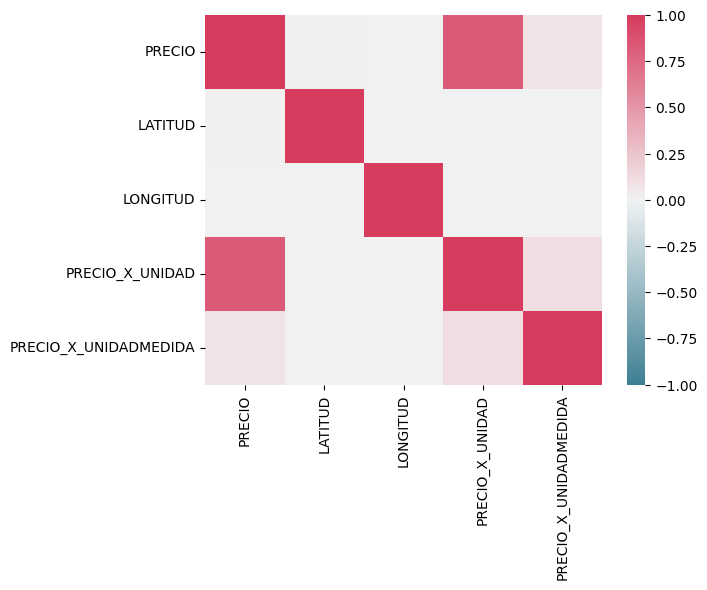

In [16]:

df_num=df_Muestra.select(variables_numericas)
sns.heatmap(df_num.to_pandas().corr(),vmax=1, vmin=-1, cmap=sns.diverging_palette(-500, 4,  as_cmap=True))

Univariado:
Una descripción básica de todas las columnas por individual

In [17]:
def Mostrar_producto(producto, df_filtrado_por_anio):
    df_filtrado_final = df_filtrado_por_anio.filter(
        pl.col("PRODUCTO") == producto
    )
    print(f"--- Resumen Estadístico para: {producto} ---")
    if df_filtrado_final.is_empty():
        print("No se encontraron datos para esta selección.")
    else:
        display(df_filtrado_final.describe())

PreguntaVerGrafica = widgets.HTML(value='<p>Seleccione sus filtros:</p>')
opciones_unicas = df_Muestra["PRODUCTO"].unique().to_list()

OpcionMultiple_VerGrafica = widgets.Dropdown(
    options=opciones_unicas,
    value='aceite',
    description='Producto:',
    disabled=False
)
AnioSlider = widgets.IntSlider(
    value=2025,
    min=2015,
    max=2025,
    step=1,
    description='Año:',
    continuous_update=False
)
salida = widgets.Output() 
def actualizar_grafico(change):
    producto_seleccionado = OpcionMultiple_VerGrafica.value
    anio_seleccionado = AnioSlider.value
    df_filtrado_anio = df_Muestra.filter(
        pl.col("FECHA_REGISTRO").dt.year() == anio_seleccionado
    )
    salida.clear_output(wait=True)
    with salida:
        Mostrar_producto(producto_seleccionado, df_filtrado_anio)
OpcionMultiple_VerGrafica.observe(actualizar_grafico, names='value')
AnioSlider.observe(actualizar_grafico, names='value')

interfaz = widgets.VBox([
    PreguntaVerGrafica,
    OpcionMultiple_VerGrafica,
    AnioSlider,
    salida
])
display(interfaz)
actualizar_grafico(None)

Bivariado:
    se muestra una box-plot según el tipo de producto y el estado

In [18]:

def Dibujar_boxplot(df, columnaDeEstudio, Etiqueta):
    
    df_filtrado_pl = df.filter(
        pl.col(columnaDeEstudio) == Etiqueta
    )
    df_filtrado_pd = df_filtrado_pl.to_pandas()
    if df_filtrado_pd.empty:
        print(f"No se encontraron datos para {columnaDeEstudio} = '{Etiqueta}'.")
        return
    plt.figure(figsize=(25, 10))
    sns.boxplot(
        data=df_filtrado_pd,
        x="ESTADO",
        y="PRECIO_X_UNIDAD",
        hue="ESTADO"
    )

    plt.title(f"PRECIO_X_UNIDAD por ESTADO \n(Filtro: {Etiqueta})")
    plt.xticks(rotation=90)
    plt.show()


In [19]:
def Dibujar_boxplot(df, columnaDeEstudio, Etiqueta):
    df_filtrado_pl = df.filter(pl.col(columnaDeEstudio) == Etiqueta)
    df_filtrado_pd = df_filtrado_pl.to_pandas()
    if df_filtrado_pd.empty:
        print(f"No se encontraron datos para {columnaDeEstudio} = '{Etiqueta}'.")
        return 
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_filtrado_pd, x="ESTADO", y="PRECIO_X_UNIDAD", hue="ESTADO")
    plt.title(f"Distribución de PRECIO_X_UNIDAD por ESTADO \n(Filtro: {Etiqueta})")
    plt.xticks(rotation=90) 
    plt.tight_layout() 
    plt.show()
PreguntaVerBoxPlot = widgets.HTML(value='<p>Seleccione el producto a analizar:</p>')
opciones_unicas = df_Muestra["PRODUCTO"].unique().to_list()

OpcionMultiple_VerBoxPlot = widgets.Dropdown(
    options=opciones_unicas,
    value='aceite',
    description='Producto:',
    disabled=False
)
salida1 = widgets.Output() 
def on_dropdown_change(change):
    producto_seleccionado = change['new']
    salida1.clear_output(wait=True)
    with salida1:
        Dibujar_boxplot(df_Muestra, "PRODUCTO", producto_seleccionado)
OpcionMultiple_VerBoxPlot.observe(on_dropdown_change, names='value')

interfaz = widgets.VBox([
    PreguntaVerBoxPlot,
    OpcionMultiple_VerBoxPlot,
    salida1
])

display(interfaz)
with salida1:
    Dibujar_boxplot(df_Muestra, "PRODUCTO", OpcionMultiple_VerBoxPlot.value)

multivariado:

Se muestra una gráfica de "PRECIO" según el "AÑO" y segun el "PRODUCTO" 

In [20]:
PreguntaVerGrafica = widgets.HTML(value='<p>Seleccione el producto a analizar:</p>')
opciones_unicas = df_Muestra["PRODUCTO"].unique().to_list()

OpcionMultiple_VerGrafica = widgets.Dropdown(
    options=opciones_unicas,
    value='aceite',
    description='Producto:',
    disabled=False
)

salida2= widgets.Output() 

def on_dropdown_change(change):
    producto_seleccionado = change['new']
    salida2.clear_output(wait=True)
    with salida2:
        graficar_producto(producto_seleccionado, df_Muestra)

OpcionMultiple_VerGrafica.observe(on_dropdown_change, names='value')

interfaz = widgets.VBox([
    PreguntaVerGrafica,
    OpcionMultiple_VerGrafica,
    salida2
])

display(interfaz)

with salida2:
    graficar_producto(OpcionMultiple_VerGrafica.value, df_Muestra)